# SWE-bench Results Comparison

Compare our Podman test results with the official submitted results for any experiment.

In [2]:
import json
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## Configuration

Select which experiment to analyze:

In [3]:
# Select experiment name
EXPERIMENT_NAME = "20250911_isea_claude-3.5-sonnet-20241022"

# Paths
BASE_DIR = Path("/fs/nexus-scratch/ihbas")
OFFICIAL_RESULTS_DIR = BASE_DIR / "generated_patches/experiments/evaluation/lite" / EXPERIMENT_NAME
OUR_RESULTS_DIR = BASE_DIR / "podman_test_results" / EXPERIMENT_NAME

print(f"Analyzing experiment: {EXPERIMENT_NAME}")
print(f"Official results: {OFFICIAL_RESULTS_DIR}")
print(f"Our results: {OUR_RESULTS_DIR}")

Analyzing experiment: 20250911_isea_claude-3.5-sonnet-20241022
Official results: /fs/nexus-scratch/ihbas/generated_patches/experiments/evaluation/lite/20250911_isea_claude-3.5-sonnet-20241022
Our results: /fs/nexus-scratch/ihbas/podman_test_results/20250911_isea_claude-3.5-sonnet-20241022


## Load Official Results

In [4]:
# Load official results
official_results_file = OFFICIAL_RESULTS_DIR / "results/results.json"

with open(official_results_file) as f:
    official_data = json.load(f)

official_resolved = set(official_data['resolved'])

print(f"Official Results:")
print(f"  Total resolved (PASS): {len(official_resolved)}")
print(f"  Total instances: 300")
print(f"  Success rate: {len(official_resolved)/300*100:.2f}%")

Official Results:
  Total resolved (PASS): 154
  Total instances: 300
  Success rate: 51.33%


## Load Our Podman Test Results

In [5]:
def load_our_results(results_dir: Path) -> Dict[str, str]:
    """Load results from our Podman tests."""
    results = {}
    
    if not results_dir.exists():
        print(f"Warning: Results directory not found: {results_dir}")
        return results
    
    # Iterate through all instance directories
    for instance_dir in results_dir.iterdir():
        if not instance_dir.is_dir():
            continue
        
        instance_id = instance_dir.name
        status_file = instance_dir / "status.txt"
        
        if status_file.exists():
            status = status_file.read_text().strip()
            results[instance_id] = status
    
    return results

our_results = load_our_results(OUR_RESULTS_DIR)

print(f"\nOur Podman Test Results:")
print(f"  Total instances tested: {len(our_results)}")

# Count by status
status_counts = {}
for status in our_results.values():
    status_counts[status] = status_counts.get(status, 0) + 1

for status, count in sorted(status_counts.items()):
    print(f"  {status}: {count}")


Our Podman Test Results:
  Total instances tested: 246
  FAIL: 125
  PASS: 121


## Compare Results

In [6]:
def compare_results(our_results: Dict[str, str], official_resolved: set) -> pd.DataFrame:
    """Compare our results with official results."""
    
    comparison_data = []
    
    for instance_id, our_status in sorted(our_results.items()):
        official_status = "PASS" if instance_id in official_resolved else "FAIL"
        
        # Normalize our status
        our_normalized = "PASS" if our_status == "PASSED" else "FAIL" if our_status == "FAILED" else our_status
        
        match = our_normalized == official_status
        
        comparison_data.append({
            'instance_id': instance_id,
            'our_status': our_status,
            'our_normalized': our_normalized,
            'official_status': official_status,
            'match': match
        })
    
    return pd.DataFrame(comparison_data)

df = compare_results(our_results, official_resolved)

# Calculate metrics
total = len(df)
matches = df['match'].sum()
mismatches = total - matches
accuracy = (matches / total * 100) if total > 0 else 0

print(f"\n{'='*70}")
print(f"COMPARISON SUMMARY")
print(f"{'='*70}")
print(f"Total instances: {total}")
print(f"Matches: {matches} ({matches/total*100:.1f}%)")
print(f"Mismatches: {mismatches} ({mismatches/total*100:.1f}%)")
print(f"Accuracy: {accuracy:.2f}%")
print(f"{'='*70}")


COMPARISON SUMMARY
Total instances: 246
Matches: 237 (96.3%)
Mismatches: 9 (3.7%)
Accuracy: 96.34%


## Detailed Breakdown

In [7]:
# Confusion matrix
confusion = pd.crosstab(
    df['our_normalized'], 
    df['official_status'],
    rownames=['Our Results'],
    colnames=['Official Results'],
    margins=True
)

print("\nConfusion Matrix:")
print(confusion)

# Calculate precision, recall, F1 for PASS category
true_positive = len(df[(df['our_normalized'] == 'PASS') & (df['official_status'] == 'PASS')])
false_positive = len(df[(df['our_normalized'] == 'PASS') & (df['official_status'] == 'FAIL')])
false_negative = len(df[(df['our_normalized'] == 'FAIL') & (df['official_status'] == 'PASS')])
true_negative = len(df[(df['our_normalized'] == 'FAIL') & (df['official_status'] == 'FAIL')])

precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nMetrics for PASS category:")
print(f"  Precision: {precision:.3f} (of tests we say PASS, how many truly PASS)")
print(f"  Recall: {recall:.3f} (of tests that should PASS, how many we caught)")
print(f"  F1 Score: {f1:.3f}")


Confusion Matrix:
Official Results  FAIL  PASS  All
Our Results                      
FAIL               116     9  125
PASS                 0   121  121
All                116   130  246

Metrics for PASS category:
  Precision: 1.000 (of tests we say PASS, how many truly PASS)
  Recall: 0.931 (of tests that should PASS, how many we caught)
  F1 Score: 0.964


## Show Mismatches

In [8]:
mismatches_df = df[~df['match']].copy()

if len(mismatches_df) > 0:
    print(f"\n⚠️  MISMATCHES ({len(mismatches_df)} instances):\n")
    
    # Group by mismatch type
    false_positives = mismatches_df[
        (mismatches_df['our_normalized'] == 'PASS') & 
        (mismatches_df['official_status'] == 'FAIL')
    ]
    
    false_negatives = mismatches_df[
        (mismatches_df['our_normalized'] == 'FAIL') & 
        (mismatches_df['official_status'] == 'PASS')
    ]
    
    print(f"False Positives (We said PASS, should be FAIL): {len(false_positives)}")
    for _, row in false_positives.head(10).iterrows():
        print(f"  • {row['instance_id']}")
    if len(false_positives) > 10:
        print(f"  ... and {len(false_positives) - 10} more")
    
    print(f"\nFalse Negatives (We said FAIL, should be PASS): {len(false_negatives)}")
    for _, row in false_negatives.head(10).iterrows():
        print(f"  • {row['instance_id']}")
    if len(false_negatives) > 10:
        print(f"  ... and {len(false_negatives) - 10} more")
else:
    print("\n✅ Perfect match! All results match official results.")


⚠️  MISMATCHES (9 instances):

False Positives (We said PASS, should be FAIL): 0

False Negatives (We said FAIL, should be PASS): 9
  • matplotlib__matplotlib-24970
  • matplotlib__matplotlib-25332
  • psf__requests-3362
  • pylint-dev__pylint-7080
  • pylint-dev__pylint-7114
  • sympy__sympy-13773
  • sympy__sympy-14817
  • sympy__sympy-15609
  • sympy__sympy-23117


## Results by Repository

In [9]:
# Extract repository from instance_id
df['repo'] = df['instance_id'].str.split('__').str[0]

# Group by repository
repo_stats = df.groupby('repo').agg({
    'match': ['count', 'sum', 'mean']
}).round(3)

repo_stats.columns = ['total', 'matches', 'accuracy']
repo_stats = repo_stats.sort_values('accuracy', ascending=False)

print("\nResults by Repository:")
print(repo_stats.to_string())


Results by Repository:
              total  matches  accuracy
repo                                  
astropy           6        6     1.000
django          114      114     1.000
mwaskom           4        4     1.000
pallets           3        3     1.000
sphinx-doc        9        9     1.000
pydata            5        5     1.000
scikit-learn     16       16     1.000
pytest-dev       15       15     1.000
matplotlib       23       21     0.913
sympy            41       37     0.902
psf               6        5     0.833
pylint-dev        4        2     0.500


## Visualizations

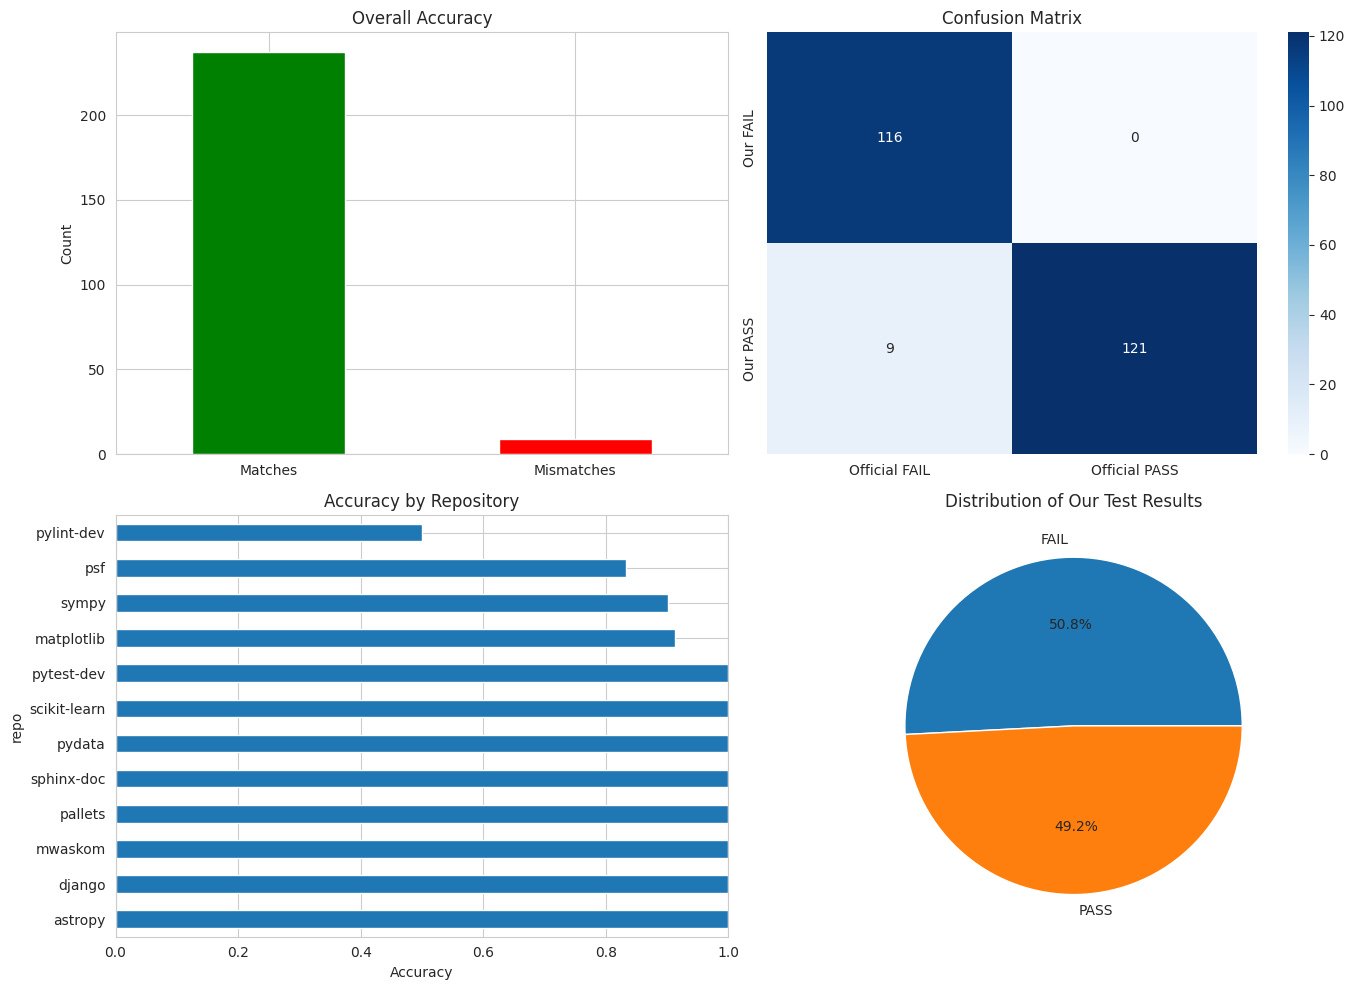


Plot saved to: /fs/nexus-scratch/ihbas/podman_test_results/20250911_isea_claude-3.5-sonnet-20241022/comparison_plots.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overall accuracy
ax = axes[0, 0]
accuracy_data = pd.Series({
    'Matches': matches,
    'Mismatches': mismatches
})
accuracy_data.plot(kind='bar', ax=ax, color=['green', 'red'])
ax.set_title('Overall Accuracy')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# 2. Confusion matrix heatmap
ax = axes[0, 1]
confusion_matrix = [[true_negative, false_positive], [false_negative, true_positive]]
sns.heatmap(confusion_matrix, annot=True, fmt='d', ax=ax, 
            xticklabels=['Official FAIL', 'Official PASS'],
            yticklabels=['Our FAIL', 'Our PASS'],
            cmap='Blues')
ax.set_title('Confusion Matrix')

# 3. Accuracy by repository
ax = axes[1, 0]
repo_stats['accuracy'].plot(kind='barh', ax=ax)
ax.set_title('Accuracy by Repository')
ax.set_xlabel('Accuracy')
ax.set_xlim([0, 1])

# 4. Status distribution
ax = axes[1, 1]
status_dist = df['our_status'].value_counts()
status_dist.plot(kind='pie', ax=ax, autopct='%1.1f%%')
ax.set_title('Distribution of Our Test Results')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(OUR_RESULTS_DIR / 'comparison_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {OUR_RESULTS_DIR / 'comparison_plots.png'}")

## Export Detailed Comparison

In [36]:
# Save detailed comparison to CSV
output_file = OUR_RESULTS_DIR / 'detailed_comparison.csv'
df.to_csv(output_file, index=False)
print(f"Detailed comparison saved to: {output_file}")

# Save summary statistics
summary = {
    'experiment': EXPERIMENT_NAME,
    'total_instances': total,
    'matches': int(matches),
    'mismatches': int(mismatches),
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'official_pass_count': len(official_resolved),
    'our_pass_count': len(df[df['our_normalized'] == 'PASS'])
}

summary_file = OUR_RESULTS_DIR / 'comparison_summary.json'
with open(summary_file, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Summary statistics saved to: {summary_file}")

Detailed comparison saved to: /fs/nexus-scratch/ihbas/podman_test_results/20250911_isea_claude-3.5-sonnet-20241022/detailed_comparison.csv
Summary statistics saved to: /fs/nexus-scratch/ihbas/podman_test_results/20250911_isea_claude-3.5-sonnet-20241022/comparison_summary.json


## Sample Mismatch Investigation

Let's look at a few mismatches in detail:

In [10]:
if len(mismatches_df) > 0:
    print("Sample mismatch details:\n")
    
    for idx, (_, row) in enumerate(mismatches_df.head(3).iterrows(), 1):
        instance_id = row['instance_id']
        instance_dir = OUR_RESULTS_DIR / instance_id
        
        print(f"{idx}. {instance_id}")
        print(f"   Our result: {row['our_status']}")
        print(f"   Official result: {row['official_status']}")
        
        # Check for test output
        test_output = instance_dir / 'test_output.txt'
        if test_output.exists():
            output = test_output.read_text()
            if 'passed' in output.lower():
                import re
                match = re.search(r'(\d+) passed', output)
                if match:
                    print(f"   Tests passed: {match.group(1)}")
        print()

Sample mismatch details:

1. matplotlib__matplotlib-24970
   Our result: FAILED
   Official result: PASS
   Tests passed: 254

2. matplotlib__matplotlib-25332
   Our result: FAILED
   Official result: PASS
   Tests passed: 182

3. psf__requests-3362
   Our result: FAILED
   Official result: PASS
   Tests passed: 76

